In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
df = pd.read_parquet("../data/ecu911_emergencias_limpio.parquet")
print(df.shape)
df.head()


(4789409, 11)


,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos,periodo,es_feriado,dia_semana
0,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Gestión Sanitaria,Problemas En El Embarazo,1,2021–2022,0,4
1,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022,0,4
2,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Resguardo A Personas Que Traslada Valores A Ni...,1,2021–2022,0,4
3,2022-04-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022,0,4
4,2022-04-01,Azuay,Cuenca,10150,"Cuenca, Cabecera Cantonal Y Capital Provincial.",Gestión De Riesgos,Amenazas Naturales,1,2021–2022,0,4


In [4]:
df_poblacion = pd.read_csv("../data/poblacion_provincias_ecuador_2022.csv")

In [5]:
df_poblacion.head()

,provincia,poblacion_2022
0,Azuay,801609.0
1,Bolivar,199078.0
2,Carchi,172828.0
3,Cañar,227578.0
4,Chimborazo,471933.0


In [6]:
import numpy as np
import pandas as pd

# Asegurar tipos correctos
df['fecha'] = pd.to_datetime(df['fecha'])
df_model = (
    df.groupby(['fecha', 'provincia'])['cantidad_eventos']
      .sum()
      .reset_index()
)


In [7]:
df_model.head()

,fecha,provincia,cantidad_eventos
0,2021-07-01,Azuay,461
1,2021-07-01,Bolivar,113
2,2021-07-01,Carchi,100
3,2021-07-01,Cañar,99
4,2021-07-01,Chimborazo,250


In [8]:
# Variables temporales
df_model['anio'] = df_model['fecha'].dt.year
df_model['mes'] = df_model['fecha'].dt.month
df_model['dia_semana'] = df_model['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df_model['es_fin_semana'] = df_model['dia_semana'].isin([4, 5, 6]).astype(int)

# Unir con población
df_model = df_model.merge(df_poblacion[['provincia', 'poblacion_2022']], on='provincia', how='left')

# Agregar feriados importantes (solo Navidad y Año Nuevo)
feriados_importantes = [
    "2021-12-25", "2022-01-01", "2022-12-25", "2023-01-01", 
    "2023-12-25", "2024-01-01", "2024-12-25", "2025-01-01"
]
df_model['es_feriado'] = df_model['fecha'].isin(pd.to_datetime(feriados_importantes)).astype(int)

# Estacionalidad (sin/cos del mes)
df_model['sin_mes'] = np.sin(2 * np.pi * df_model['mes'] / 12)
df_model['cos_mes'] = np.cos(2 * np.pi * df_model['mes'] / 12)


In [9]:
df_model.head()

,fecha,provincia,cantidad_eventos,anio,mes,dia_semana,es_fin_semana,poblacion_2022,es_feriado,sin_mes,cos_mes
0,2021-07-01,Azuay,461,2021,7,3,0,801609.0,0,-0.5,-0.866025
1,2021-07-01,Bolivar,113,2021,7,3,0,199078.0,0,-0.5,-0.866025
2,2021-07-01,Carchi,100,2021,7,3,0,172828.0,0,-0.5,-0.866025
3,2021-07-01,Cañar,99,2021,7,3,0,227578.0,0,-0.5,-0.866025
4,2021-07-01,Chimborazo,250,2021,7,3,0,471933.0,0,-0.5,-0.866025


In [10]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36542 entries, 0 to 36541
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             36542 non-null  datetime64[ns]
 1   provincia         36542 non-null  object        
 2   cantidad_eventos  36542 non-null  int64         
 3   anio              36542 non-null  int32         
 4   mes               36542 non-null  int32         
 5   dia_semana        36542 non-null  int32         
 6   es_fin_semana     36542 non-null  int64         
 7   poblacion_2022    36542 non-null  float64       
 8   es_feriado        36542 non-null  int64         
 9   sin_mes           36542 non-null  float64       
 10  cos_mes           36542 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int32(3), int64(3), object(1)
memory usage: 2.6+ MB


In [11]:
# Target
y = df_model['cantidad_eventos']

# Features (todas las variables predictoras exógenas)
X = df_model.drop(columns=['cantidad_eventos', 'fecha'])


In [12]:
fecha_min = df_model['fecha'].min()
fecha_max = df_model['fecha'].max()

# Determinar punto de corte (80% del rango)
split_point = fecha_min + (fecha_max - fecha_min) * 0.8
print(f"Punto de corte temporal (80/20): {split_point:%Y-%m-%d}")

Punto de corte temporal (80/20): 2024-10-30


In [20]:
mask_train = df_model['fecha'] < split_point
mask_test = df_model['fecha'] >= split_point

X_train, X_test = X[mask_train], X[mask_test]
y_train, y_test = y[mask_train], y[mask_test]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (29222, 9), Test: (7320, 9)


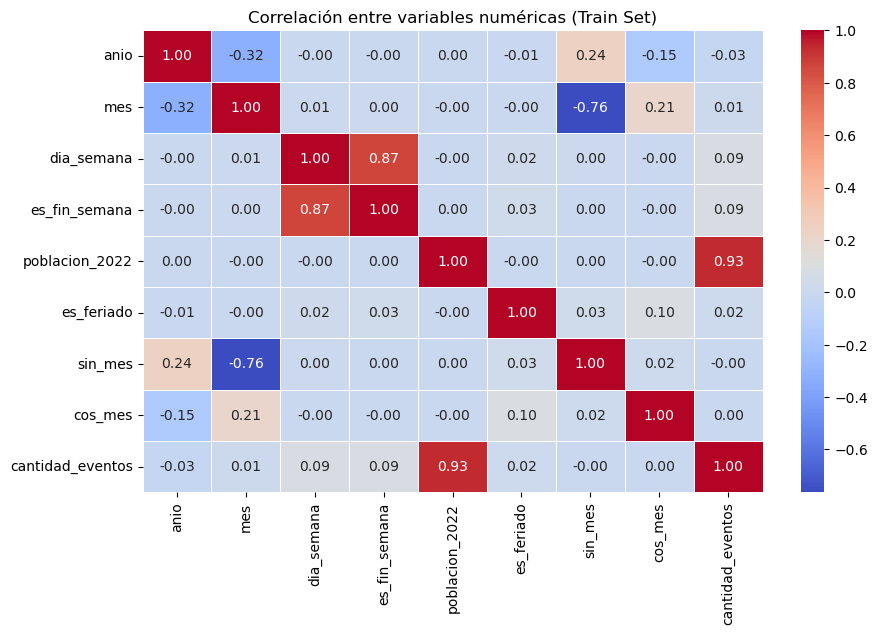

In [22]:
import seaborn as sns

# Combinar X_train e y_train para análisis
df_corr = X_train.copy()
df_corr['cantidad_eventos'] = y_train.values

# Correlación solo numérica
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlación entre variables numéricas (Train Set)")
plt.show()

In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_features = ['provincia']
num_features = ['anio', 'mes', 'dia_semana', 'es_fin_semana', 'es_feriado',
                'poblacion_2022', 'sin_mes', 'cos_mes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', 'passthrough', num_features)
    ])


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Pipeline completo
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.3f}")


MAE:  40.21
RMSE: 88.89
R²:   0.977


/tmp/ipykernel_2793/1002873096.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='viridis')


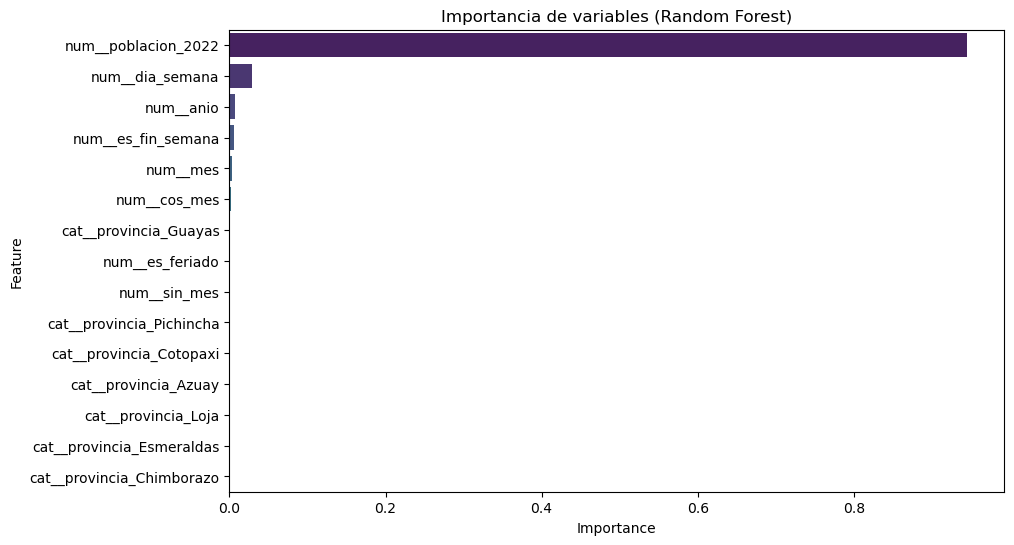

In [26]:
# Extraer nombres de columnas tras el OneHotEncoder
feature_names = model.named_steps['preprocess'].get_feature_names_out()

# Importancias
importances = model.named_steps['rf'].feature_importances_

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='viridis')
plt.title("Importancia de variables (Random Forest)")
plt.show()


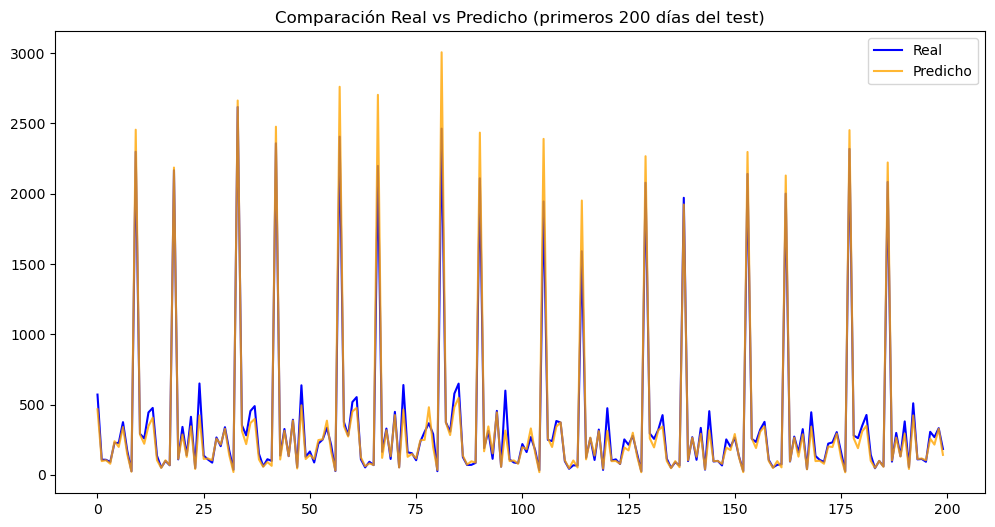

In [27]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Real', color='blue')
plt.plot(y_pred[:200], label='Predicho', color='orange', alpha=0.8)
plt.title("Comparación Real vs Predicho (primeros 200 días del test)")
plt.legend()
plt.show()


In [28]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')
print(f"R² promedio CV: {scores.mean():.3f} ± {scores.std():.3f}")


R² promedio CV: 0.979 ± 0.008


In [29]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Definir el modelo base
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Definir grilla de parámetros
param_grid = {
    'rf__n_estimators': [100, 150, 200],
    'rf__max_depth': [8, 10, 12],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 3, 5],
    'rf__max_features': ['sqrt', 0.5, None],
}

# Pipeline (igual que antes)
model_gs = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', rf_base)
])

# Validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search
gs = GridSearchCV(
    estimator=model_gs,
    param_grid=param_grid,
    scoring='r2',
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

# Entrenamiento
gs.fit(X_train, y_train)

print("✅ Mejor combinación encontrada:")
print(gs.best_params_)
print(f"Mejor R² promedio CV: {gs.best_score_:.3f}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   1.9s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=150; total time=   1.3s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=10, rf__n_estimators=100; total time=   2.1s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=2, rf__n_estimators=100; total time=   1.9s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=5, rf__n_estimators=100; total time=   1.4s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=5, rf__n_estimators=200; total time=   2.3s
[CV] END rf__max_depth=8, rf__max_features=sqrt, rf__min_samples_leaf=5, rf__min_samples_split=2, rf_

In [30]:
best_model = gs.best_estimator_
best_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred_best = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.3f}")


MAE:  38.57
RMSE: 86.85
R²:   0.978

[CV] END rf__max_depth=12, rf__max_features=0.5, rf__min_samples_leaf=3, rf__min_samples_split=5, rf__n_estimators=150; total time=  12.1s
[CV] END rf__max_depth=12, rf__max_features=0.5, rf__min_samples_leaf=3, rf__min_samples_split=10, rf__n_estimators=200; total time=  21.6s
[CV] END rf__max_depth=12, rf__max_features=0.5, rf__min_samples_leaf=5, rf__min_samples_split=10, rf__n_estimators=100; total time=  13.4s
[CV] END rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=150; total time=  32.0s
[CV] END rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=10, rf__n_estimators=100; total time=  16.8s
[CV] END rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=3, rf__min_samples_split=2, rf__n_estimators=100; total time=  16.7s
[CV] END rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=3, rf__min_samples_split=5, rf__n_estimators=100; to

In [36]:
X_test

,provincia,anio,mes,dia_semana,es_fin_semana,poblacion_2022,es_feriado,sin_mes,cos_mes
29222,Azuay,2024,10,3,0,801609.0,0,-0.866025,0.5
29223,Bolivar,2024,10,3,0,199078.0,0,-0.866025,0.5
29224,Carchi,2024,10,3,0,172828.0,0,-0.866025,0.5
29225,Cañar,2024,10,3,0,227578.0,0,-0.866025,0.5
29226,Chimborazo,2024,10,3,0,471933.0,0,-0.866025,0.5
...,...,...,...,...,...,...,...,...,...
36537,Santa Elena,2025,8,6,1,385735.0,0,-0.866025,-0.5
36538,Santo Domingo De Los Tsachilas,2025,8,6,1,492969.0,0,-0.866025,-0.5
36539,Sucumbios,2025,8,6,1,199014.0,0,-0.866025,-0.5
36540,Tungurahua,2025,8,6,1,563532.0,0,-0.866025,-0.5


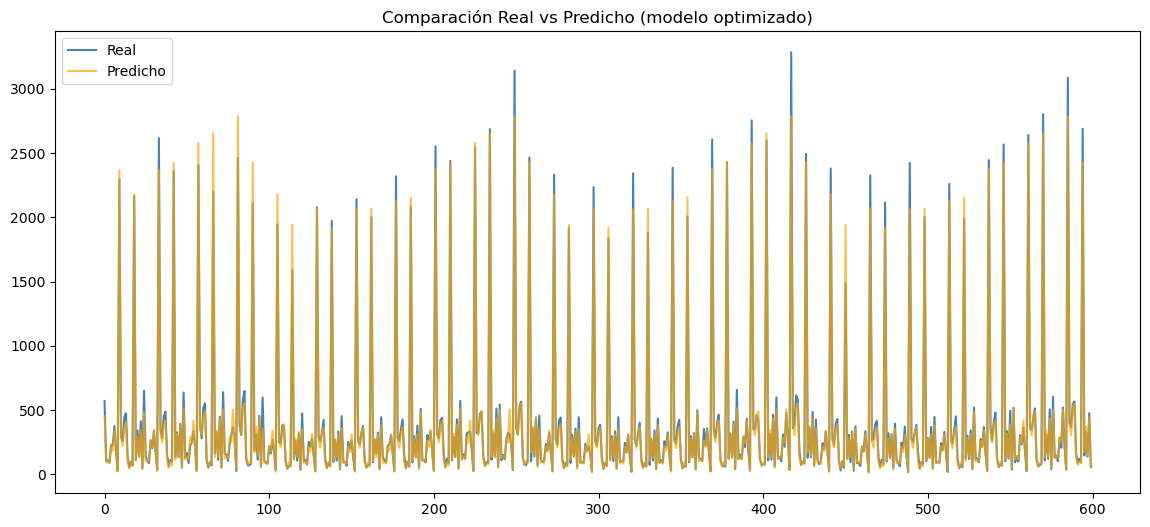

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.values[:600], label='Real', color='steelblue')
plt.plot(y_pred_best[:600], label='Predicho', color='orange', alpha=0.7)
plt.legend()
plt.title("Comparación Real vs Predicho (modelo optimizado)")
plt.show()


In [38]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

model_xgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,     # regularización L2
        reg_alpha=0.3,      # regularización L1
        random_state=42,
        n_jobs=-1
    ))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")


MAE: 39.55
RMSE: 87.98
R²: 0.977


In [39]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('gb', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"R² GradientBoosting: {r2_gb:.3f}")


R² GradientBoosting: 0.977


In [40]:
from sklearn.linear_model import LinearRegression

model_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('lr', LinearRegression())
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"R² LinearRegression: {r2_lr:.3f}")


R² LinearRegression: 0.895


In [41]:
from sklearn.linear_model import Ridge

model_ridge = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('ridge', Ridge(alpha=1.0))
])

model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"R² Ridge: {r2_ridge:.3f}")


R² Ridge: 0.895


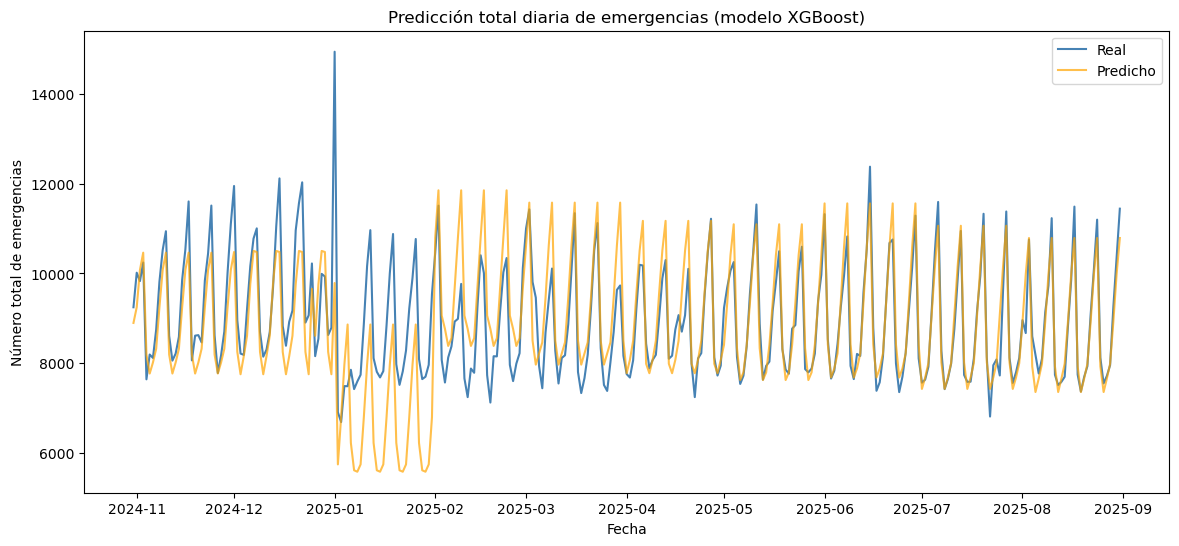

In [42]:
df_results = df_model.loc[mask_test, ['fecha', 'provincia']]
df_results['real'] = y_test.values
df_results['predicho'] = y_pred_xgb

# Agregar a nivel nacional
df_diario = df_results.groupby('fecha')[['real', 'predicho']].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(df_diario['fecha'], df_diario['real'], label='Real', color='steelblue')
plt.plot(df_diario['fecha'], df_diario['predicho'], label='Predicho', color='orange', alpha=0.7)
plt.title("Predicción total diaria de emergencias (modelo XGBoost)")
plt.xlabel("Fecha")
plt.ylabel("Número total de emergencias")
plt.legend()
plt.show()


In [43]:
mae_prov = df_results.groupby('provincia').apply(
    lambda g: mean_absolute_error(g['real'], g['predicho'])
).reset_index(name='MAE')

mae_prov = mae_prov.sort_values('MAE', ascending=False)
print(mae_prov.head(10))


     provincia         MAE
9       Guayas  205.772522
18   Pichincha  203.331039
0        Azuay   57.925629
12    Los Rios   45.636509
13      Manabi   44.689411
6       El Oro   35.322792
11        Loja   33.091003
22  Tungurahua   32.979889
10    Imbabura   31.871792
7   Esmeraldas   29.063038


/tmp/ipykernel_2793/1285967682.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_prov = df_results.groupby('provincia').apply(


In [44]:
import numpy as np

mape_prov = df_results.groupby('provincia').apply(
    lambda g: np.mean(np.abs((g['real'] - g['predicho']) / g['real'])) * 100
).reset_index(name='MAPE (%)')

mape_prov = mape_prov.sort_values('MAPE (%)', ascending=False)
print(mape_prov.head(10))


           provincia   MAPE (%)
16          Orellana  20.243518
14   Morona Santiago  20.231310
8          Galapagos  19.858480
23  Zamora Chinchipe  17.575367
7         Esmeraldas  15.540151
17           Pastaza  15.327617
15              Napo  15.297815
3              Cañar  14.364512
21         Sucumbios  13.792268
19       Santa Elena  13.778789


/tmp/ipykernel_2793/3735612440.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mape_prov = df_results.groupby('provincia').apply(


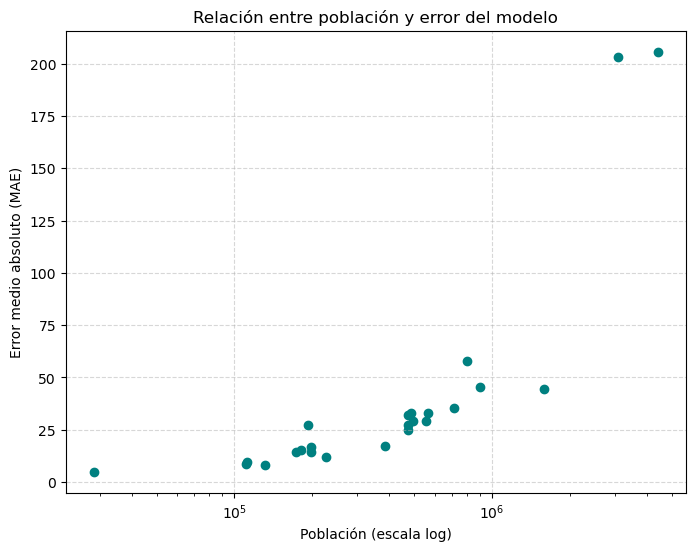

In [45]:
import matplotlib.pyplot as plt

df_merge = mae_prov.merge(df_poblacion, on='provincia')
plt.figure(figsize=(8,6))
plt.scatter(df_merge['poblacion_2022'], df_merge['MAE'], color='teal')
plt.xscale('log')
plt.xlabel("Población (escala log)")
plt.ylabel("Error medio absoluto (MAE)")
plt.title("Relación entre población y error del modelo")
plt.grid(True, ls='--', alpha=0.5)
plt.show()


In [46]:
import joblib

joblib.dump(model_xgb, "../data/modelo_emergencias_xgb_final.pkl")
print("Modelo XGBoost guardado con éxito.")


Modelo XGBoost guardado con éxito.


# Clasificaciones

In [58]:
# Total diario por provincia y servicio
df_grouped = (
    df.groupby(['fecha', 'provincia', 'servicio'])['cantidad_eventos']
      .sum()
      .reset_index()
)


In [59]:
# Calcular ranking interno
df_grouped['rank'] = df_grouped.groupby(['fecha', 'provincia'])['cantidad_eventos'] \
                               .rank(ascending=False, method='first')

# Quedarnos con los 4 más importantes
df_top4 = df_grouped[df_grouped['rank'] <= 4].reset_index(drop=True)


In [60]:
df_top4.head()

,fecha,provincia,servicio,cantidad_eventos,rank
0,2021-07-01,Azuay,Gestión Sanitaria,100,2.0
1,2021-07-01,Azuay,Seguridad Ciudadana,223,1.0
2,2021-07-01,Azuay,Servicios Municipales,49,4.0
3,2021-07-01,Azuay,Tránsito Y Movilidad,71,3.0
4,2021-07-01,Bolivar,Gestión Sanitaria,17,2.0


In [61]:
df_top4['anio'] = df_top4['fecha'].dt.year
df_top4['mes'] = df_top4['fecha'].dt.month
df_top4['dia_semana'] = df_top4['fecha'].dt.dayofweek  # 0 = lunes
df_top4['es_fin_semana'] = df_top4['dia_semana'].isin([4,5,6]).astype(int)

# Feriados mayores
feriados = pd.to_datetime([
    "2021-12-25", "2022-01-01", "2022-12-25", "2023-01-01",
    "2023-12-25", "2024-01-01", "2024-12-25", "2025-01-01"
])
df_top4['es_feriado'] = df_top4['fecha'].isin(feriados).astype(int)

# Representación estacional (sin/cos)
df_top4['sin_mes'] = np.sin(2 * np.pi * df_top4['mes'] / 12)
df_top4['cos_mes'] = np.cos(2 * np.pi * df_top4['mes'] / 12)


In [62]:
features = [
    'provincia', 'anio', 'mes', 'dia_semana',
    'es_fin_semana', 'es_feriado', 'sin_mes', 'cos_mes'
]

target = 'servicio'

X = df_top4[features]
y = df_top4[target]


In [64]:
mask_train = df_top4['fecha'] < split_point
mask_test = df_top4['fecha'] >= split_point

X_train, X_test = X[mask_train], X[mask_test]
y_train, y_test = y[mask_train], y[mask_test]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (114888, 8), Test: (29110, 8)


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Codificar etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Pipeline
cat_features = ['provincia']
num_features = [c for c in X.columns if c not in cat_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', 'passthrough', num_features)
])

model_servicios = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('xgb', XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
model_servicios.fit(X_train, y_train_enc)

# Evaluar
y_pred = model_servicios.predict(X_test)
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


                       precision    recall  f1-score   support

   Gestión De Riesgos       0.16      0.02      0.04       470
Gestión De Siniestros       0.00      0.00      0.00      1653
    Gestión Sanitaria       0.25      0.24      0.25      7267
  Seguridad Ciudadana       0.25      0.53      0.34      7320
     Servicio Militar       0.25      0.02      0.04      3273
Servicios Municipales       0.25      0.02      0.03      2659
 Tránsito Y Movilidad       0.24      0.23      0.23      6468

             accuracy                           0.25     29110
            macro avg       0.20      0.15      0.13     29110
         weighted avg       0.23      0.25      0.21     29110



/home/brandon/micromamba/envs/DS/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/brandon/micromamba/envs/DS/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/brandon/micromamba/envs/DS/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [66]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train_enc)


,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    top_k_accuracy_score
)
import numpy as np

# === Predicciones ===
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)

# === Métricas básicas ===
acc = accuracy_score(y_test_enc, y_pred_rf)
print(f"✅ Accuracy global: {acc:.3f}\n")

# === Reporte detallado ===
print("📊 Classification report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le.classes_))

# === Matriz de confusión (opcional) ===
cm = confusion_matrix(y_test_enc, y_pred_rf)
print("\n🔹 Matriz de confusión:")
print(cm)

# === Métrica Top-4 Accuracy ===
top4_acc = top_k_accuracy_score(y_test_enc, y_proba_rf, k=4)
print(f"\n🎯 Top-4 Accuracy: {top4_acc:.3f}")


✅ Accuracy global: 0.160

📊 Classification report:
                       precision    recall  f1-score   support

   Gestión De Riesgos       0.07      0.47      0.12       470
Gestión De Siniestros       0.14      0.39      0.20      1653
    Gestión Sanitaria       0.25      0.00      0.00      7267
  Seguridad Ciudadana       0.25      0.02      0.04      7320
     Servicio Militar       0.16      0.61      0.26      3273
Servicios Municipales       0.20      0.55      0.29      2659
 Tránsito Y Movilidad       0.23      0.02      0.04      6468

             accuracy                           0.16     29110
            macro avg       0.19      0.30      0.14     29110
         weighted avg       0.22      0.16      0.09     29110


🔹 Matriz de confusión:
[[ 223   53    0   20  101   69    4]
 [ 139  642    2   36  664  138   32]
 [ 856 1163   14  163 3073 1842  156]
 [ 857 1165   14  170 3114 1844  156]
 [ 423  360    9   99 2011  249  122]
 [ 217  116    4   48  807 1460    7]
 

In [68]:
import joblib

# === Guardar modelo y encoder ===
joblib.dump(model_rf, "../data/modelo_servicios_rf.pkl")
joblib.dump(le, "../data/label_encoder_servicios.pkl")

print("✅ Modelo y encoder guardados correctamente.")


✅ Modelo y encoder guardados correctamente.
